In [60]:
#Cease & Desist Document Processing System

# Install all required libraries
# Run this once per Colab session

!pip install langgraph langchain langchain-groq \
             langchain-community pymupdf pypdf -q

print("Libraries installed")

Libraries installed


In [61]:
# Load Groq API key from Colab Secrets

import os
from google.colab import userdata

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

print("API Key loaded")

API Key loaded


In [62]:
# Reads all PDFs from /content/Input_Folder

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from pathlib import Path

PDF_FOLDER = "/content/Input_Folder"
pdf_files  = list(Path(PDF_FOLDER).glob("*.pdf"))

docs = []
for pdf_path in pdf_files:
    loader = PyPDFLoader(str(pdf_path))
    pages  = loader.load()
    if pages:
        full_text = "\n\n".join([p.page_content for p in pages])
        docs.append(Document(
            page_content = full_text,
            metadata     = {"source": str(pdf_path)}
        ))

print(f"Loaded {len(docs)} documents from {PDF_FOLDER}")
print()
for doc in docs:
    name   = doc.metadata["source"].split("/")[-1]
    chars  = len(doc.page_content.strip())
    print(f" Name : {name}--- Chars: {chars}")

Loaded 29 documents from /content/Input_Folder

 Name : 07_software_license_violation.pdf--- Chars: 3497
 Name : bw_doc_1.pdf--- Chars: 0
 Name : LOA8.pdf--- Chars: 4446
 Name : bw_doc_3.pdf--- Chars: 0
 Name : 06_harassment_workplace.pdf--- Chars: 3329
 Name : notice_5.pdf--- Chars: 0
 Name : LOA6.pdf--- Chars: 3015
 Name : 04_defamation_online_review.pdf--- Chars: 3303
 Name : notice_4.pdf--- Chars: 0
 Name : 10_breach_of_contract_nda.pdf--- Chars: 3876
 Name : LOA5.pdf--- Chars: 1702
 Name : LOA3.pdf--- Chars: 1701
 Name : 09_copyright_infringement_music.pdf--- Chars: 3535
 Name : notice_3.pdf--- Chars: 0
 Name : LOA2.pdf--- Chars: 1695
 Name : LOA9.pdf--- Chars: 4880
 Name : bw_doc_5.pdf--- Chars: 0
 Name : notice_2.pdf--- Chars: 0
 Name : bw_doc_2.pdf--- Chars: 0
 Name : 08_non_compete_violation.pdf--- Chars: 3696
 Name : 01_copyright_infringement_photography.pdf--- Chars: 3154
 Name : LoA1.pdf--- Chars: 1680
 Name : 03_trade_secret_misappropriation.pdf--- Chars: 3528
 Name : LOA7

In [63]:
# 1. Text LLM  → classify and extract text from documents
# 2. Vision LLM → read scanned PDFs (images)

from langchain_groq import ChatGroq

llm = ChatGroq(
    model       = "llama-3.1-8b-instant",
    temperature = 0
)

vision_llm = ChatGroq(
    model       = "meta-llama/llama-4-scout-17b-16e-instruct",
    temperature = 0
)

print(f"Text LLM   : {llm.model_name}")
print(f"Vision LLM : {vision_llm.model_name}")

Text LLM   : llama-3.1-8b-instant
Vision LLM : meta-llama/llama-4-scout-17b-16e-instruct


In [64]:
# Creating 2 db to capture Cases & Audit Logs
# cease_cases.db  → stores valid cases
# audit_log.db    →  Captures logs in each step

import sqlite3
from datetime import datetime, timezone

CEASE_DB = "/content/cease_cases.db"
AUDIT_DB = "/content/audit_log.db"

def now():
    return datetime.now(timezone.utc).isoformat()

# Cease cases table
con = sqlite3.connect(CEASE_DB)
con.execute("""
    CREATE TABLE IF NOT EXISTS cease_cases (
        case_id           TEXT PRIMARY KEY,
        doc_name          TEXT,
        received_at       TEXT,
        sender            TEXT,
        classification    TEXT,
        confidence_score  REAL,
        reasoning         TEXT,
        final_action      TEXT,
        is_human_involved TEXT,
        created_at        TEXT
    )
""")
con.commit()
con.close()
print("Created 'cease_cases' table")

# Audit log table
con = sqlite3.connect(AUDIT_DB)
con.execute("""
    CREATE TABLE IF NOT EXISTS audit_log (
        id                INTEGER PRIMARY KEY AUTOINCREMENT,
        case_id           TEXT,
        doc_name          TEXT,
        received_at       TEXT,
        step_number       INTEGER,
        agent_name        TEXT,
        step_status       TEXT,
        doc_status        TEXT,
        classification    TEXT,
        confidence_score  REAL,
        reasoning         TEXT,
        final_action      TEXT,
        is_human_involved TEXT,
        tokens_input      INTEGER,
        tokens_output     INTEGER,
        tokens_total      INTEGER,
        time_taken        REAL,
        error_message     TEXT,
        logged_at         TEXT
    )
""")
con.commit()
con.close()
print("Created 'audit_log' table")

Created 'cease_cases' table
Created 'audit_log' table


In [65]:
# Functions to create \ update database tables

import sqlite3

# Generate unique case ID cd_<<counter>>_<<TimeStamp>>
case_counter = 1
def generate_case_id():
    global case_counter
    ts      = datetime.now(timezone.utc).strftime("%Y%m%d%H%M%S")
    case_id = f"cd_{case_counter:03d}_{ts}"
    case_counter += 1
    return case_id

# Save cease case to DB
def insert_cease_case(case_id, doc_name, received_at, sender,
                      classification, confidence_score, reasoning,
                      final_action, is_human_involved):
    con = sqlite3.connect(CEASE_DB)
    con.execute(
        "INSERT OR REPLACE INTO cease_cases VALUES (?,?,?,?,?,?,?,?,?,?)",
        (case_id, doc_name, received_at, sender, classification,
         confidence_score, reasoning, final_action, is_human_involved, now())
    )
    con.commit()
    con.close()

# Log every agent step to audit
def insert_audit_log(case_id, doc_name, received_at, step_number,
                     agent_name, step_status, doc_status=None,
                     classification=None, confidence_score=None,
                     reasoning=None, final_action=None,
                     is_human_involved="no", tokens_input=0,
                     tokens_output=0, tokens_total=0,
                     time_taken=0.0, error_message=None):
    con = sqlite3.connect(AUDIT_DB)
    con.execute(
        "INSERT INTO audit_log VALUES (NULL,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)",
        (case_id, doc_name, received_at, step_number, agent_name,
         step_status, doc_status, classification, confidence_score,
         reasoning, final_action, is_human_involved, tokens_input,
         tokens_output, tokens_total, time_taken, error_message, now())
    )
    con.commit()
    con.close()

print("Create DB Functions")

Create DB Functions


In [66]:
# (7) Memory

from langgraph.checkpoint.memory import InMemorySaver

# LangGraph checkpointer — saves full state
checkpointer = InMemorySaver()

# Simple session memory list
memory_store = []

def save_to_memory(doc_name, doc_type, confidence, reasoning):
    """Called after each doc is classified."""
    memory_store.append({
        "doc_name"  : doc_name,
        "doc_type"  : doc_type,
        "confidence": confidence,
        "reasoning" : reasoning,
    })

def view_memory():
    """Print all docs processed this session."""
    print(f"\nSession Memory — {len(memory_store)} docs processed:")
    print("--------------------------------")
    if not memory_store:
        print("  Empty")
        return
    for i, m in enumerate(memory_store):
        icon = "M:CD" if m["doc_type"] == "cease"      else \
               "M:Irrelevant" if m["doc_type"] == "irrelevant"  else \
               "M:Uncertain" if m["doc_type"] == "uncertain"  else \
               "UnKnown"
        print(f"  {i+1}. {icon} {m['doc_name']}")
        print(f"      Type: {m['doc_type']} | Confidence: {m['confidence']}")
        print()

print("Created Memory")

Created Memory


In [67]:
# Tools
# PDF Tool: Load & Exract Text
# OCR Tool : to get text from image
# Save DB Tool: To update db with contents
# Archive Tool: to Archive irrelevant data


import fitz
import base64
from pathlib import Path
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_community.document_loaders import PyPDFLoader


@tool
def load_pdf_tool(pdf_path: str) -> str:
    """Load and extract text from a normal PDF file."""
    loader = PyPDFLoader(pdf_path)
    pages  = loader.load()
    return "\n\n".join([p.page_content for p in pages]) if pages else ""


@tool
def ocr_tool(pdf_path: str) -> str:
    """Extract text from scanned PDF using Vision LLM."""
    if not Path(pdf_path).exists():
        return ""
    full_text = ""
    pdf       = fitz.open(pdf_path)
    for page_num in range(len(pdf)):
        page    = pdf[page_num]
        pix     = page.get_pixmap(matrix=fitz.Matrix(2, 2))
        img_b64 = base64.b64encode(pix.tobytes("png")).decode("utf-8")
        res     = vision_llm.invoke([HumanMessage(content=[
            {"type": "text",
             "text": "Extract all text from this document. Return only the text."},
            {"type": "image_url",
             "image_url": {"url": f"data:image/png;base64,{img_b64}"}}
        ])])
        full_text += res.content.strip() + "\n"
    pdf.close()
    return full_text.strip()


@tool
def save_to_db_tool(case_id: str, doc_name: str, received_at: str,
                    sender: str, classification: str,
                    confidence_score: float, reasoning: str,
                    is_human_involved: str) -> str:
    """Save cease case to database."""
    insert_cease_case(case_id, doc_name, received_at, sender,
                      classification, confidence_score, reasoning,
                      "added_to_db", is_human_involved)
    return f"Saved {doc_name}"


@tool
def archive_tool(case_id, doc_name, confidence_score,
                 received_at, reasoning) -> str:
    """Archive irrelevant document to flat file."""
    line = (f"DATE={received_at[:10]}  CASE={case_id}  "
            f"FILE={doc_name} Confidence Score = {confidence_score} REASON={reasoning[:60]}\n")
    with open("/content/irrelevant_archive.txt", "a") as f:
        f.write(line)
    return f"Archived {doc_name}"


print("Created Tools")
print("load_pdf_tool , ocr_tool, save_to_db_tool, archive_tool")

Created Tools
load_pdf_tool , ocr_tool, save_to_db_tool, archive_tool


In [68]:
# State for Langraph
# Defines State (Doc) for process

import uuid
from typing import Optional, Annotated
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langgraph.graph.message import add_messages


class DocumentState(TypedDict):
    # Document info — Start
    case_id      : str
    doc_name     : str
    doc_text     : str
    received_at  : str
    doc_status   : Optional[str]
    doc_chunks   : Optional[list]
    chunk_count  : Optional[int]

    # Classification — classification agent
    doc_type         : Optional[str]
    confidence_score : Optional[float]
    reasoning        : Optional[str]
    extracted_data   : Optional[dict]

    # Human review — HITL agent
    human_decision   : Optional[str]
    human_notes      : Optional[str]

    # Final result —  DB/archive agent
    final_action      : Optional[str]
    is_human_involved : Optional[str]

    # Token tracking — classification agent
    tokens_input  : Optional[int]
    tokens_output : Optional[int]
    tokens_total  : Optional[int]

    # Step tracking — to capture all steps\Agent
    current_step  : Optional[int]
    step_name     : Optional[str]
    error_message : Optional[str]

    # LangGraph annotations
    messages : Annotated[list, add_messages]


def create_state(doc: Document) -> DocumentState:
    """Create a fresh state for each new document."""
    return DocumentState(
        case_id           = generate_case_id(),
        doc_name          = doc.metadata["source"].split("/")[-1],
        doc_text          = doc.page_content,
        received_at       = now(),
        doc_status        = None,
        doc_chunks   = [],
        chunk_count  = 0,
        doc_type          = None,
        confidence_score  = None,
        reasoning         = None,
        extracted_data    = None,
        human_decision    = None,
        human_notes       = None,
        final_action      = None,
        is_human_involved = "no",
        tokens_input      = 0,
        tokens_output     = 0,
        tokens_total      = 0,
        current_step      = 0,
        step_name         = "init",
        error_message     = None,
        messages          = [],
    )

print("Created State Schema")

Created State Schema


In [69]:
# Agent 1: Document Loader
# Reads PDF text. If empty (scanned PDF) → uses Vision model via ocr_tool.

import time
from langchain_text_splitters import RecursiveCharacterTextSplitter


splitter = RecursiveCharacterTextSplitter(
    chunk_size    = 2500,
    chunk_overlap = 100,
)


def document_loader_agent(state: DocumentState) -> dict:
    print(f"\nLoading: {state['doc_name']}")
    start = time.time()

    # Log init step
    insert_audit_log(
        state["case_id"], state["doc_name"],
        state["received_at"], 1, "init", "started"
    )

    text = state["doc_text"].strip()

    if len(text) > 50:
        doc_status = "text"
        print(f"   {len(text)} chars extracted")

    else:
        doc_status = "scanned"
        print(f"   No text - trying Vision model...")
        try:
            pdf_path = str(Path(PDF_FOLDER) / state["doc_name"])
            text     = ocr_tool.invoke({"pdf_path": pdf_path})
            if len(text.strip()) > 50:
                doc_status = "text"
                print(f"   Vision extracted {len(text)} chars")
            else:
                doc_status = "empty"
                print(f"   Vision returned empty")
        except Exception as e:
            doc_status = "empty"
            print(f"   Vision error: {e}")

    # Split text into chunks
    if doc_status == "text":
        chunks     = splitter.split_text(text)
        chunk_count = len(chunks)
        print(f"   Split into {chunk_count} chunks")
        for i, chunk in enumerate(chunks):
            print(f"   Chunk {i+1} : {len(chunk)} chars")
    else:
        chunks      = []
        chunk_count = 0

    # Log result
    insert_audit_log(
        state["case_id"], state["doc_name"],
        state["received_at"], 1,
        "document_loader_agent", "completed",
        doc_status = doc_status,
        time_taken = round(time.time()-start, 2)
    )

    return {
        "doc_text"    : text,
        "doc_chunks"  : chunks,        # all chunks stored in state
        "chunk_count" : chunk_count,   # how many chunks
        "doc_status"  : doc_status,
        "current_step": 1,
        "step_name"   : "document_loader_agent",
    }

print("Created **Document Loader Agent**")

Created **Document Loader Agent**


In [70]:
### System Prompt

SYSTEM_PROMPT = """You are an expert legal document classifier specializing
in Cease and Desist letters with 20 years of experience.

TASK:
Read the document carefully and classify it into one of three categories.
Extract key details only if it is a valid Cease and Desist letter.

CLASSIFICATION

cease
  The document has all of the following:
  - Clear legal demands asking someone to stop an activity
  - Identifies both sender and receiver
  - References a specific violation or harm caused
  - States or implies legal consequences for non-compliance
  - Written by or on behalf of an attorney or rights holder
  Common violations include copyright, trademark, patent,
  defamation, harassment, breach of NDA, trade secret, debt collection.

uncertain
  The document has some legal language but:
  - Missing one or more key elements of a cease and desist
  - Demands are vague or not clearly asking to stop something
  - Sender or receiver cannot be clearly identified
  - Wording is deliberately ambiguous
  - Not confident enough to classify as cease or irrelevant

irrelevant
  The document is not a cease and desist letter.
  Examples: invoice, letter of authorization, business correspondence,
  contract, newsletter, power of attorney, general complaint or inquiry.

CONFIDENCE SCORE

0.80 to 1.00  All key elements clearly present. Very confident.
0.50 to 0.79  Most elements present but some are missing.
0.00 to 0.49  Vague or missing key elements. Classify as uncertain.

EXTRACTION

Only extract fields when classification is cease.
Set extracted_data to null for uncertain and irrelevant.

Fields to extract:
  sender         - Full name and company of the sender
  receiver       - Full name and company of the receiver
  violation_type - The law or right that was violated
  demands        - List of specific demands made
  deadline       - Response deadline or null
  cited_laws     - Laws or statutes cited or null
  damages        - Damage amount mentioned or null

OUTPUT

Return only this JSON with no extra text:
{{
  "classification" : "cease or uncertain or irrelevant",
  "confidence"     : 0.0 to 1.0,
  "reasoning"      : "one sentence explaining the decision",
  "extracted_data" : {{
    "sender"         : "...",
    "receiver"       : "...",
    "violation_type" : "...",
    "demands"        : ["demand 1", "demand 2"],
    "deadline"       : "date or null",
    "cited_laws"     : ["law 1", "law 2"],
    "damages"        : "amount or null"
  }} or null
}}"""

print("Defined System Prompt for classification and extraction")

Defined System Prompt for classification and extraction


In [71]:
# Agent 2 : Classification Agent

import time
import json
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.messages import SystemMessage, HumanMessage

# Build runnable chain once
# Uses SYSTEM_PROMPT defined in Cell 11
prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("human",  "{doc_text}")
])

parser = JsonOutputParser()

def classify_chunk(chunk_text: str) -> dict:
    """
    Send one chunk to LLM and get classification result.
    Returns dict with classification, confidence, reasoning, extracted_data
    and token counts.
    """
    full_response = ""
    tokens_input = tokens_output = tokens_total = 0

    # Format prompt with chunk text
    messages = prompt.format_messages(doc_text=chunk_text)

    # Stream response
    for chunk in llm.stream(messages):
        print(chunk.content, end="", flush=True)
        full_response += chunk.content
        if hasattr(chunk, "usage_metadata") and chunk.usage_metadata:
            tokens_input  = chunk.usage_metadata.get("input_tokens",  0)
            tokens_output = chunk.usage_metadata.get("output_tokens", 0)
            tokens_total  = chunk.usage_metadata.get("total_tokens",  0)
    print()

    # Json Response
    raw = full_response.strip()
    if "```" in raw:
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    if "{" in raw:
        raw = raw[raw.index("{"):]
    if "}" in raw:
        raw = raw[:raw.rindex("}")+1]
    raw = raw.strip()


    result = json.loads(raw)

    # Add token counts to result
    result["tokens_input"]  = tokens_input
    result["tokens_output"] = tokens_output
    result["tokens_total"]  = tokens_total

    return result


# Merge Splitted Chunks with priority rule
def merge_results(chunk_results: list) -> dict:
    """
    Merge results from all chunks into one final result.

    Priority Rule:
      If ANY chunk says cease with confidence >= 0.80
      the whole document is cease.

      This is because a C&D letter only needs
      ONE section with legal demands to be valid.

    For other types:
      Pick highest confidence result.

    For extracted fields:
      Lists   → combine all items, remove duplicates
      Strings → take first non-null value found
    """

    # Find all cease results with high confidence
    cease_results = [
        r for r in chunk_results
        if r.get("classification") == "cease"
        and float(r.get("confidence", 0)) >= 0.80
    ]

    non_cease_results = [
        r for r in chunk_results
        if r.get("classification") != "cease"
    ]

    print(f"\n   Cease chunks     : {len(cease_results)}")
    print(f"   Non-cease chunks : {len(non_cease_results)}")


    if cease_results:
        best = max(cease_results, key=lambda x: float(x.get("confidence", 0)))
        print(f"   Decision : CEASE found in {len(cease_results)} chunk(s)")
    else:
        best = max(chunk_results, key=lambda x: float(x.get("confidence", 0)))
        print(f"   Decision : No cease → {best.get('classification')}")

    # Extracted Result from merged result
    merged_extracted = {}
    for r in chunk_results:
        data = r.get("extracted_data") or {}
        for key, val in data.items():
            if val and val != "null":

                if isinstance(val, list):
                    existing = merged_extracted.get(key, [])
                    merged_extracted[key] = list(set(existing + val))

                elif key not in merged_extracted:
                    merged_extracted[key] = val

    # Tokens for Audit Logs
    total_tokens_input  = sum(r.get("tokens_input",  0) for r in chunk_results)
    total_tokens_output = sum(r.get("tokens_output", 0) for r in chunk_results)
    total_tokens_total  = sum(r.get("tokens_total",  0) for r in chunk_results)

    return {
        "classification" : best.get("classification"),
        "confidence"     : best.get("confidence"),
        "reasoning"      : best.get("reasoning"),
        "extracted_data" : merged_extracted or None,
        "tokens_input"   : total_tokens_input,
        "tokens_output"  : total_tokens_output,
        "tokens_total"   : total_tokens_total,
    }


# Classification Agent
def classification_agent(state: DocumentState) -> dict:
    print(f"\nClassifying: {state['doc_name']}")
    start = time.time()

    # Ignore emopty text
    if state.get("doc_status") in ["empty", "failed"]:
        print(f"   Skipping - doc is {state['doc_status']}")
        insert_audit_log(
            state["case_id"], state["doc_name"],
            state["received_at"], 2,
            "classification_agent", "skipped",
            doc_status = state["doc_status"]
        )
        return {"current_step": 2, "step_name": "classification_agent"}

    try:
        chunks = state.get("doc_chunks") or [state["doc_text"]]
        print(f"   Processing {len(chunks)} chunk(s)...")

        # Process each chunk with LLM Call
        chunk_results = []
        for i, chunk_text in enumerate(chunks):
            print(f"\n   Chunk {i+1} of {len(chunks)} :")
            print(f"   Streaming : ", end="", flush=True)
            try:
                result = classify_chunk(chunk_text)
                chunk_results.append(result)
                print(f"   Chunk {i+1} result : {result.get('classification')} | confidence : {result.get('confidence')}")
            except Exception as e:
                print(f"   Chunk {i+1} failed : {e}")
                continue


        if not chunk_results:
            raise Exception("All chunks failed to classify")

        merged = merge_results(chunk_results)

        classification   = merged["classification"]
        confidence_score = float(merged["confidence"])
        reasoning        = merged["reasoning"]
        extracted_data   = merged["extracted_data"]
        tokens_input     = merged["tokens_input"]
        tokens_output    = merged["tokens_output"]
        tokens_total     = merged["tokens_total"]

        # Apply confidence rules
        if confidence_score >= 0.80:
            final_type = classification
        elif confidence_score >= 0.50:
            final_type = "uncertain"
        else:
            final_type = "irrelevant"

        print(f"\n   Final Result     : {final_type.upper()}")
        print(f"   Confidence       : {confidence_score}")
        print(f"   Reasoning        : {reasoning}")
        print(f"   Total Tokens     : {tokens_total}")
        print(f"   Chunks processed : {len(chunk_results)}")

        # Save to memory (Lab 6)
        save_to_memory(
            state["doc_name"],
            final_type,
            confidence_score,
            reasoning
        )

        # Log to audit
        insert_audit_log(
            state["case_id"], state["doc_name"],
            state["received_at"], 2,
            "classification_agent", "completed",
            doc_status       = state["doc_status"],
            classification   = final_type,
            confidence_score = confidence_score,
            reasoning        = reasoning,
            tokens_input     = tokens_input,
            tokens_output    = tokens_output,
            tokens_total     = tokens_total,
            time_taken       = round(time.time()-start, 2)
        )

        return {
            "doc_type"        : final_type,
            "confidence_score": confidence_score,
            "reasoning"       : reasoning,
            "extracted_data"  : extracted_data,
            "tokens_input"    : tokens_input,
            "tokens_output"   : tokens_output,
            "tokens_total"    : tokens_total,
            "current_step"    : 2,
            "step_name"       : "classification_agent",
        }

    except Exception as e:
        print(f"\n   Error: {e}")
        insert_audit_log(
            state["case_id"], state["doc_name"],
            state["received_at"], 2,
            "classification_agent", "failed",
            error_message = str(e),
            time_taken    = round(time.time()-start, 2)
        )
        return {
            "error_message": str(e),
            "current_step" : 2,
            "step_name"    : "classification_agent"
        }

In [72]:
# Agent 3: Database Agent
# Runs only for cease documents.
# Reads extracted_data from state
# Updates save_to_db_tool to write to db.

import time

def database_agent(state: DocumentState) -> dict:
    print(f"\nSaving to DB: {state['doc_name']}")
    start = time.time()

    try:
        data = state.get("extracted_data") or {}

        print(f"   Sender    : {data.get('sender',         'N/A')}")
        print(f"   Violation : {data.get('violation_type', 'N/A')}")
        print(f"   Deadline  : {data.get('deadline',       'N/A')}")

        # Use save_to_db_tool
        save_to_db_tool.invoke({
            "case_id"          : state["case_id"],
            "doc_name"         : state["doc_name"],
            "received_at"      : state["received_at"],
            "sender"           : data.get("sender", "unknown"),
            "classification"   : state["doc_type"],
            "confidence_score" : state["confidence_score"],
            "reasoning"        : state["reasoning"],
            "is_human_involved": state.get("is_human_involved", "no"),
        })

        print(f"  Saved to cease_cases DB")

        insert_audit_log(
            state["case_id"], state["doc_name"],
            state["received_at"], 3,
            "database_agent", "completed",
            classification    = state["doc_type"],
            confidence_score  = state["confidence_score"],
            final_action      = "added_to_db",
            is_human_involved = state.get("is_human_involved", "no"),
            #tokens_total      = state.get("tokens_total", 0),
            tokens_total = 0,
            time_taken        = round(time.time()-start, 2)
        )

        return {
            "final_action": "added_to_db",
            "current_step": 3,
            "step_name"   : "database_agent"
        }

    except Exception as e:
        print(f"  Error: {e}")
        return {
            "error_message": str(e),
            "current_step" : 3,
            "step_name"    : "database_agent"
        }

print("Created *Database Agent*")

Created *Database Agent*


In [73]:
# Agent 4: Archiving Agent
# Runs for irrelevant documents.
# Uses archive_tool to write txt file

import time

def archiving_agent(state: DocumentState) -> dict:
    print(f"\n Archiving: {state['doc_name']}")
    start = time.time()

    try:
        # Use archive_tool (Lab 4)
        archive_tool.invoke({
            "case_id"    : state["case_id"],
            "doc_name"   : state["doc_name"],
            "received_at": state["received_at"],
            "confidence_score": state["confidence_score"],
            "reasoning"  : state.get("reasoning", ""),
        })

        print(f"  Archived to /content/irrelevant_archive.txt")

        insert_audit_log(
            state["case_id"], state["doc_name"],
            state["received_at"], 3,
            "archiving_agent", "completed",
            classification    = state["doc_type"],
            final_action      = "archived",
            is_human_involved = state.get("is_human_involved", "no"),
            time_taken        = round(time.time()-start, 2)
        )

        return {
            "final_action": "archived",
            "current_step": 3,
            "step_name"   : "archiving_agent"
        }

    except Exception as e:
        print(f"    Error: {e}")
        return {
            "error_message": str(e),
            "current_step" : 3,
            "step_name"    : "archiving_agent"
        }

print("Created *Archiving Agent*")

Created *Archiving Agent*


In [74]:
# Used by human_review_agent when human approves uncertain doc

EXTRACTION_PROMPT = """You are a legal data extractor.
Extract all key fields from this Cease and Desist letter.

Return only this JSON with no extra text:
{
  "sender"         : "full name and company of sender",
  "receiver"       : "full name and company of receiver",
  "violation_type" : "type of violation",
  "demands"        : ["demand 1", "demand 2"],
  "deadline"       : "response deadline or null",
  "cited_laws"     : ["law 1", "law 2"],
  "damages"        : "damage amount or null"
}"""

print("Defined Extraction prompt for human in the loop")

Defined Extraction prompt for human in the loop


In [75]:
# Agent 5: Human in the Loop Agent
# For irrelevant docs waits for human to take decision
# Approved move data to db else move to archive
# Uses Extraction Prompt
import time
import json
from langgraph.types import interrupt
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

# Build extraction chain once using Runnables
# Uses EXTRACTION_PROMPT from Cell 10b
extract_prompt = ChatPromptTemplate.from_messages([
    ("system", EXTRACTION_PROMPT),
    ("human",  "{doc_text}")
])

extract_chain = extract_prompt | llm | JsonOutputParser()

def human_review_agent(state: DocumentState) -> dict:

    print(f"\nHUMAN REVIEW REQUIRED")
    print(f"   {'='*45}")
    print(f"   Case ID    : {state['case_id']}")
    print(f"   Document   : {state['doc_name']}")
    print(f"   AI said    : UNCERTAIN")
    print(f"   Confidence : {state['confidence_score']}")
    print(f"   Reason     : {state['reasoning']}")
    print(f"   Preview    : {state['doc_text'][:150]}...")
    print(f"   {'='*45}")
    print(f"\n   Graph paused - run Cell 19 to decide!")

    # Capture Audit Logs
    insert_audit_log(
        state["case_id"], state["doc_name"],
        state["received_at"], 4,
        "human_review_agent", "waiting",
        classification    = "uncertain",
        is_human_involved = "yes"
    )

    # Setup HITL
    human_input = interrupt({
        "case_id" : state["case_id"],
        "doc_name": state["doc_name"],
        "message" : "approve_as_cease or reject_as_irrelevant"
    })

    # With Human Decision
    decision = human_input.get("decision", "reject_as_irrelevant")
    notes    = human_input.get("notes", "")

    # If Approve - store data in DB
    if decision == "approve_as_cease":
        new_doc_type = "cease"
        print(f"\n   Approved - extracting fields...")

        try:

            extracted_data = extract_chain.invoke({
                "doc_text": state["doc_text"][:3000]
            })

            print(f"   Sender    : {extracted_data.get('sender',         'N/A')}")
            print(f"   Receiver  : {extracted_data.get('receiver',       'N/A')}")
            print(f"   Violation : {extracted_data.get('violation_type', 'N/A')}")
            print(f"   Deadline  : {extracted_data.get('deadline',       'N/A')}")

        except Exception as e:
            print(f"   Extraction failed: {e}")
            extracted_data = {}

    # Else Reject - consider this as irrelevant
    else:
        new_doc_type   = "irrelevant"
        extracted_data = None
        print(f"\n   Rejected - going to Archive")

    # Capture completion Log
    insert_audit_log(
        state["case_id"], state["doc_name"],
        state["received_at"], 4,
        "human_review_agent", "completed",
        classification    = new_doc_type,
        is_human_involved = "yes"
    )

    return {
        "doc_type"         : new_doc_type,
        "extracted_data"   : extracted_data,
        "human_decision"   : decision,
        "human_notes"      : notes,
        "is_human_involved": "yes",
        "current_step"     : 4,
        "step_name"        : "human_review_agent",
    }

print("Created *Human Review Agent*")

Created *Human Review Agent*


In [76]:
# Agent 6: Audit Agent
# captures step wise logs as audit logs for all docs
# Writes final summary to audit_log table.
# Captures: doc type, action taken, tokens used, time taken etc.

import time

def audit_agent(state: DocumentState) -> dict:
    print(f"\nAudit: {state['doc_name']}")

    insert_audit_log(
        state["case_id"], state["doc_name"],
        state["received_at"], 5,
        "audit_agent", "completed",
        doc_status        = state.get("doc_status"),
        classification    = state.get("doc_type"),
        confidence_score  = state.get("confidence_score"),
        reasoning         = state.get("reasoning"),
        final_action      = state.get("final_action"),
        is_human_involved = state.get("is_human_involved", "no"),
        tokens_input      = state.get("tokens_input",  0),
        tokens_output     = state.get("tokens_output", 0),
        tokens_total = 0,
        error_message     = state.get("error_message")
    )

    print(f"  Audit logged!")
    return {"current_step": 5, "step_name": "audit_agent"}

print("Created *Audit Agent*")

Created *Audit Agent*


In [77]:
# Define LangGraph
# Doc - Cease_Decease -- DB ;uncertain-- archive; Conditional - Irrelevant -- Human review ( Approve - DB _ Reject - Archive)

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command


# Route after classification
def route_after_classifier(state: DocumentState) -> str:
    if state.get("doc_status") in ["empty", "failed"]:
        return "audit"
    doc_type = state.get("doc_type")
    if doc_type == "cease":      return "database"
    if doc_type == "irrelevant": return "archive"
    return "human_review"


# Route after human review
# human_review_agent already updated doc_type
# so we just check doc_type again
def route_after_human_review(state: DocumentState) -> str:
    if state.get("doc_type") == "cease":
        return "database"
    return "archive"


def build_graph():
    g = StateGraph(DocumentState)

    # Setup All Agents
    g.add_node("document_loader", document_loader_agent)
    g.add_node("classifier",      classification_agent)
    g.add_node("database",        database_agent)
    g.add_node("archive",         archiving_agent)
    g.add_node("human_review",    human_review_agent)
    g.add_node("audit",           audit_agent)

    # Setup Start point
    g.add_edge(START,             "document_loader")
    g.add_edge("document_loader", "classifier")

    # Conditional Edges from classifier
    g.add_conditional_edges(
        "classifier",
        route_after_classifier,
        {
            "database"    : "database",
            "archive"     : "archive",
            "human_review": "human_review",
            "audit"       : "audit",
        }
    )

    # Conditional Edges : Human in the looop
    g.add_conditional_edges(
        "human_review",
        route_after_human_review,
        {
            "database": "database",
            "archive" : "archive",
        }
    )

    # Setup END Point
    g.add_edge("database", "audit")
    g.add_edge("archive",  "audit")
    g.add_edge("audit",    END)

    # interrupt_before = HITL middleware
    # Pauses graph before human_review node
    return g.compile(
        checkpointer     = checkpointer,
        interrupt_before = ["human_review"],
    )


graph = build_graph()

print("State Graph Defined")
print("Doc - Cease_Decease -- DB ;uncertain-- archive; ")
print("Conditional - Uncertain -- Human review ( Approve - DB _ Reject - Archive)")

State Graph Defined
Doc - Cease_Decease -- DB ;uncertain-- archive; 
Conditional - Uncertain -- Human review ( Approve - DB _ Reject - Archive)


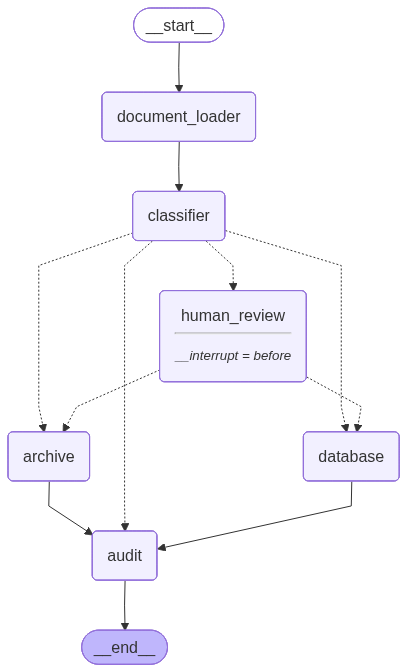

In [78]:
# Visualize the LangGraph pipeline as a diagram

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [79]:
# Runs all docs defined
# Stores result in results[]
# Added delay between docs for 3 secs


import time
from datetime import datetime, timezone

print("=" * 55)
print("  CEASE & DESIST SYSTEM — PROCESSING")
print("=" * 55)
print(f"  Total : {len(docs)} documents")
print(f"  Start : {now()[:19]}")
print("=" * 55)

results = []

for i, doc in enumerate(docs):
    print(f"\n{'─'*55}")
    print(f"  Doc {i+1} of {len(docs)}")
    print(f"{'─'*55}")

    state  = create_state(doc)
    config = {"configurable": {"thread_id": state["case_id"]}}

    try:
        result = graph.invoke(state, config=config)
        results.append({
            "doc_name"      : result["doc_name"],
            "case_id"       : result["case_id"],
            "doc_type"      : result.get("doc_type")          or "unknown",
            "confidence"    : result.get("confidence_score"),
            "final_action"  : result.get("final_action")      or "N/A",
            "human_involved": result.get("is_human_involved") or "no",
            "status"        : "completed",
            "config"        : config,
        })
    except Exception as e:
        print(f"  {e}")
        results.append({
            "doc_name"      : doc.metadata["source"].split("/")[-1],
            "case_id"       : state["case_id"],
            "doc_type"      : "unknown",
            "confidence"    : None,
            "final_action"  : "failed",
            "human_involved": "no",
            "status"        : "failed",
            "config"        : config,
        })

    time.sleep(3)   # pause between docs to avoid rate limit

  CEASE & DESIST SYSTEM — PROCESSING
  Total : 29 documents
  Start : 2026-03-22T12:36:36

───────────────────────────────────────────────────────
  Doc 1 of 29
───────────────────────────────────────────────────────

Loading: 07_software_license_violation.pdf
   3497 chars extracted
   Split into 2 chunks
   Chunk 1 : 1927 chars
   Chunk 2 : 1568 chars

Classifying: 07_software_license_violation.pdf
   Processing 2 chunk(s)...

   Chunk 1 of 2 :
   Streaming : {
  "classification" : "cease",
  "confidence"     : 1.0,
  "reasoning"      : "The document clearly states a formal demand to cease and desist, identifies both sender and receiver, references a specific violation, and states legal consequences for non-compliance.",
  "extracted_data" : {
    "sender"         : "Michael Brennan, Esq., General Counsel, Forge Software Inc.",
    "receiver"       : "Ms. Claire Dubois, VP of Engineering, Apex Consulting Group LLC",
    "violation_type" : "Copyright infringement, Computer Fraud and A

In [80]:
#Human Review - Get input from User
#Filter results with "uncertain"
#Pause for human approval : Y -Approve ; N - reject

from langgraph.types import Command

uncertain_cases = [r for r in results if r["doc_type"] == "uncertain"]

if not uncertain_cases:
    print("No uncertain cases - skip this cell!")

else:
    print(f"  {len(uncertain_cases)} uncertain case(s) waiting for review:")
    print()

    # Get all uncertain cases
    for i, c in enumerate(uncertain_cases):
        print(f"  [{i}] {c['doc_name']}")
        print(f"       Case ID : {c['case_id'][:12]}")
    print()

    # loop with uncertain cases
    for case in uncertain_cases:

        print(f"{'='*55}")
        print(f"  Document : {case['doc_name']}")
        print(f"  Case ID  : {case['case_id'][:12]}")
        print(f"{'='*55}")
        print()
        print("  What is your decision?")
        print("  y → approve as cease      (save to DB)")
        print("  n → reject as irrelevant  (archive)")
        print()

        # Get user input for approve or reject
        choice = input("  Enter y or n : ").strip().lower()
        notes  = input("  Enter reason or comments : ").strip()

        # Map to decision
        if choice == "y":
            decision = "approve_as_cease"
        else:
            decision = "reject_as_irrelevant"

        print(f"\n  Decision : {decision}")
        print(f"  Notes    : {notes}")
        print(f"  Resuming graph...")

        # Resume graph from paused state
        resumed = graph.invoke(
            Command(resume={
                "decision": decision,
                "notes"   : notes,
            }),
            config = case["config"],
        )

        # Get final outcome from resumed graph
        final_doc_type    = resumed.get("doc_type")
        final_action      = resumed.get("final_action")
        human_involved    = resumed.get("is_human_involved")

        # Update results[] with final outcome
        # So Cell 22 summary shows correct counts
        for r in results:
            if r["case_id"] == case["case_id"]:
                r["doc_type"]       = final_doc_type  or r["doc_type"]
                r["final_action"]   = final_action    or r["final_action"]
                r["human_involved"] = human_involved  or "yes"
                r["status"]         = "completed"
                print(f"  Results updated for : {r['doc_name']}")
                break

  4 uncertain case(s) waiting for review:

  [0] notice_4.pdf
       Case ID : cd_009_20260
  [1] notice_3.pdf
       Case ID : cd_014_20260
  [2] notice_2.pdf
       Case ID : cd_018_20260
  [3] notice_1.pdf
       Case ID : cd_029_20260

  Document : notice_4.pdf
  Case ID  : cd_009_20260

  What is your decision?
  y → approve as cease      (save to DB)
  n → reject as irrelevant  (archive)

  Enter y or n : y
  Enter reason or comments : Failed

  Decision : approve_as_cease
  Notes    : Failed
  Resuming graph...

HUMAN REVIEW REQUIRED
   Case ID    : cd_009_20260322123815
   Document   : notice_4.pdf
   AI said    : UNCERTAIN
   Confidence : 0.6
   Reason     : The document has some legal language but is intentionally non-prescriptive and lacks clear demands to stop an activity.
   Preview    : Bannister, Kline & Co.
44 Oakwell Chambers, Central Row

Data Privacy & Outreach Unit
Date: October 10, 2025

On behalf of our client, whom we identif...

   Graph paused - run Cell 19 to 

In [81]:
# View all data stored during processing:
# 1. Cease cases database
# 2. Irrelevant archive file
# 3. Audit log
# 4. Session memory

import sqlite3

# Cease cases
print("CEASE CASES DB:")
print("=" * 70)
print(f"  {'CASE ID':<15} {'DOC NAME':<40} {'SENDER':<25} {'TYPE':<12} {'CONF':<6} {'HUMAN'}")
con  = sqlite3.connect(CEASE_DB)
rows = con.execute(
    "SELECT case_id, doc_name, sender, classification, confidence_score, is_human_involved FROM cease_cases Order by case_id"
).fetchall()
con.close()
if rows:
    #print(rows)
    for r in rows:
        print(f"  {r[0][:12]} | {r[1]:40s} | {r[2]:20s} | {r[3]:10s} | {r[4]} | human={r[5]}")
else:
    print("  No records!")

# Archive file
print(f"\n IRRELEVANT ARCHIVE:")
print("=" * 70)
try:
    print(open("/content/irrelevant_archive.txt").read())
except:
    print("  No archived docs!")

# Audit log

print(f"\nAUDIT LOG:")
print("=" * 70)
print(f"  {'CASE ID':<13} {'DOC NAME':<47} {'AgentName':<27} {'Step Status':<13} {'Type':<13} {'Tokens':<5} {'Time Taken'}")
con  = sqlite3.connect(AUDIT_DB)
rows = con.execute(
    """
    SELECT case_id, doc_name, agent_name,
           step_status, classification, tokens_total, time_taken
    FROM   audit_log
    ORDER  BY logged_at
"""
).fetchall()
con.close()
for r in rows:
    print(f"  {r[0][:12]} | {r[1]:45s} | {r[2]:25s} | {r[3]:10s} | {str(r[4]):12s} | {str(r[5]):5s} | {r[6]}s")

# Memory
print()
#view_memory()

CEASE CASES DB:
  CASE ID         DOC NAME                                 SENDER                    TYPE         CONF   HUMAN
  cd_001_20260 | 07_software_license_violation.pdf        | Michael Brennan, Esq., General Counsel, Forge Software Inc. | cease      | 1.0 | human=no
  cd_003_20260 | LOA8.pdf                                 | Cordoba Legal Group, LLC, 102 NE 2nd Street #252, Boca Raton, FL 33432 | cease      | 0.9 | human=no
  cd_005_20260 | 06_harassment_workplace.pdf              | Linda Fujimoto, on behalf of herself | cease      | 1.0 | human=no
  cd_008_20260 | 04_defamation_online_review.pdf          | Dr. Samantha Ellis, Owner, Ellis Integrative Health Clinic | cease      | 1.0 | human=no
  cd_009_20260 | notice_4.pdf                             | unknown              | cease      | 0.6 | human=yes
  cd_010_20260 | 10_breach_of_contract_nda.pdf            | Karen Whitfield, Esq., Managing Partner, Whitfield & Chang LLP | cease      | 1.0 | human=no
  cd_013_20260 | 09_c

In [82]:
# Final Summary — each doc and its status
print("FINAL DOCUMENT SUMMARY")
print("=" * 70)
print(f"  {'#':<4} {'FILE':<40} {'TYPE':<12} {'ACTION':<15} {'HUMAN'}")
print(f"  {'-'*4} {'-'*40} {'-'*12} {'-'*15} {'-'*6}")

for i, r in enumerate(results):
    print(f"  {i+1:<4} {r['doc_name']:<40} {r['doc_type']:<12} {r['final_action']:<15} {r['human_involved']}")
print()
print("=" * 70)
#File Level Information
print("status before Human Review")
print("=" * 70)
print(f"  {'Classification':<15}  {'Count':<5}")
con  = sqlite3.connect(AUDIT_DB)
rows = con.execute(
    """SELECT
       classification,
        COUNT(*) as count
    FROM   audit_log
    WHERE  agent_name  = 'classification_agent'
    AND    step_status = 'completed'
    GROUP  BY classification
    ORDER  BY count DESC
"""
).fetchall()
con.close()
for r in rows:
    print(f"  {r[0]:<15}  {r[1]:<5}")
print()
print("=" * 70)
print("status After Human Review")
print("=" * 70)
print(f"\n  Total     : {len(results)}")
print(f"  Cease     : {sum(1 for r in results if r['doc_type'] == 'cease')}")
print(f"  Irrelevant: {sum(1 for r in results if r['doc_type'] == 'irrelevant')}")
print(f"  Uncertain : {sum(1 for r in results if r['doc_type'] == 'uncertain')}")
print(f"  Failed    : {sum(1 for r in results if r['doc_type'] == 'unknown')}")
print()
print("=" * 70)

FINAL DOCUMENT SUMMARY
  #    FILE                                     TYPE         ACTION          HUMAN
  ---- ---------------------------------------- ------------ --------------- ------
  1    07_software_license_violation.pdf        cease        added_to_db     no
  2    bw_doc_1.pdf                             irrelevant   archived        no
  3    LOA8.pdf                                 cease        added_to_db     no
  4    bw_doc_3.pdf                             irrelevant   archived        no
  5    06_harassment_workplace.pdf              cease        added_to_db     no
  6    notice_5.pdf                             irrelevant   archived        no
  7    LOA6.pdf                                 irrelevant   archived        no
  8    04_defamation_online_review.pdf          cease        added_to_db     no
  9    notice_4.pdf                             cease        added_to_db     yes
  10   10_breach_of_contract_nda.pdf            cease        added_to_db     no
  11   LO